# Survival Analysis: Time to Defibrillation vs. Patient Outcomes (Exponential Fit)
This notebook analyzes the Out-of-Hospital Cardiac Arrest (OHCA) clinical dataset to model the relationship between response delays and patient survivability. 

Specifically, it isolates the **Time to First Defibrillation** (in minutes) and evaluates its impact on two key metrics:
* **Overall Survival**: Probability of a patient ultimately surviving the incident.
* **Neurological Outcome (CPC)**: Probability of a Good Cerebral Performance Category score (CPC 1 or 2).

This analysis groups response times into 1-minute bins and utilizes **exponential decay curve fitting** (`scipy.optimize.curve_fit`) to establish a continuous mathematical baseline showing how survival probability degrades over time.

# Need to install decryption Libraries

In [25]:
%pip install msoffcrypto-tool openpyxl

Note: you may need to restart the kernel to use updated packages.


# Install libraries

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import msoffcrypto
import io
import openpyxl

from pathlib import Path
from scipy.optimize import curve_fit

# Get the password from env

In [27]:
password = os.getenv("PAROS_PASSWORD")

if not password:
    print("ERROR: Password not found in the env")
else:
    print("SUCCESS: Password found in the env")

SUCCESS: Password found in the env


# Setting up file paths

In [28]:
CURRENT_DIRECTORY = Path(os.getcwd())
BASE_DATASET_PATH = CURRENT_DIRECTORY.parents[0] / "datasets"
ENCRYPTED_FILE_PATH = BASE_DATASET_PATH / "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"

display(ENCRYPTED_FILE_PATH)


PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets/DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx')

# Decrypting the file

In [29]:
decrypted_workbook = io.BytesIO()
print(f"Attempting to decrypt: {ENCRYPTED_FILE_PATH.name}...")

try:
    with open(ENCRYPTED_FILE_PATH, 'rb') as file:
        office_file = msoffcrypto.OfficeFile(file)
        office_file.load_key(password=password)
        office_file.decrypt(decrypted_workbook)

    # Load the decrypted memory object directly into a Pandas DataFrame
    df = pd.read_excel(decrypted_workbook)
    print("✅ RAW PAROS dataset successfully decrypted and loaded!")
    
    # Show the first 3 rows to confirm
    # display(df.head(3))

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at {ENCRYPTED_FILE_PATH}. Please check the path and filename.")
except openpyxl.utils.exceptions.InvalidFileException:
    print("❌ Error: Invalid password or unsupported Excel format.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

Attempting to decrypt: DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx...


/opt/miniconda3/envs/geospatial_env/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ RAW PAROS dataset successfully decrypted and loaded!


# Setting columns for feature engineering

In [30]:
# This will be used to calculate time to defib
call_time_col = 'Time call received at dispatch center'
shock_time_col = 'Time of first shock given'

# This will be used to calculate into a binary status of 0/1 survival
status_col = 'Patient status'

# This will be used for CPC analysis
cpc_col = 'Patient neurological status - Cerebral'

df_survival = df.copy()
# display(df_survival[[call_time_col, shock_time_col, status_col, cpc_col]].head())

# Calculating the time to defib

In [31]:
df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
                                          format = "mixed",
                                          errors='coerce')
df_survival['Shock_Time'] = pd.to_datetime(df_survival[shock_time_col].astype(str),
                                           format='mixed',
                                           errors='coerce')

# Calculate the difference in minutes
df_survival['Time_to_Defib'] = (df_survival['Shock_Time'] - df_survival['Call_Time']).dt.total_seconds() / 60

# Fix midnight crossover overlaps
df_survival.loc[df_survival['Time_to_Defib'] < 0, 'Time_to_Defib'] += 1440

# display(df_survival[['Call_Time', 'Shock_Time', 'Time_to_Defib']].head(10))

Time to defib will show 13.9 minutes (standard decimal format)

Example (Index 0):
-   54 seconds ÷ 60 seconds = 0.90 minutes.
-   13 minutes + 0.90 minutes = 13.90 minutes.

# Feature Engineering for Survival Status

- 0 = Dead
- 1 = Survived

In [32]:
df_survival['Survival_Status'] = ~df_survival[status_col].astype(str).str.contains('Dead|Died',
                                                                                   case=False,
                                                                                   na=False)
df_survival['Survival_Status'] = df_survival['Survival_Status'].astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status']].head())

# Feature Engineering for CPC Status

-   1 = Good (CPS 1-2)
-   0 = Bad (CPC 3-5)

In [33]:
df_survival['CPC_Status'] = df_survival[cpc_col].astype(str).str.contains('1|2',
                                                                          regex=True).astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status', 'CPC_Status']].head(10))

# Creating a clean dataframe for analysis

-   Create 1-minute bins (0, 1, 2, 3... up to max cutoff)

In [34]:
df_clean = df_survival.dropna(subset=["Time_to_Defib", "Survival_Status", "CPC_Status"]).copy()

# Keeping response time based off the max time
max_time = 20
df_clean = df_clean[df_clean['Time_to_Defib'] <= max_time]
df_clean['Time_Bin'] = np.floor(df_clean['Time_to_Defib']).astype(int)

# display(df_clean[['Time_to_Defib', 'Time_Bin', 'Survival_Status', 'CPC_Status']].head(10))

# Calculate the probability of survival for each 1-minute bin

In [35]:
survival_prob = df_clean.groupby('Time_Bin')['Survival_Status'].mean().reset_index()
survival_prob.columns = ['Time_Bin', 'EST_Probability']

# display(survival_prob.head())

# Calculate probability of a good CPC outcome for each 1-minute bin

In [36]:
# Create binary CPC column (1-2 = 1, 3-5 =0)
df_clean["CPC_Good_Binary"] = df_clean["CPC_Status"].apply(lambda x: 1 if x in [1,2] else 0)

# Calculate the probability of good CPC outcome by time bin
cpc_prob = df_clean.groupby('Time_Bin')['CPC_Good_Binary'].mean().reset_index()
cpc_prob.columns = ['Time_Bin', 'CPC_Good_Probability']

# display(cpc_prob.head())


# Creating Exponential Curve fitting

-   Use a standard exponential function and SciPy to find the best mathematical fit

In [37]:
def exponential_decay(t, a, b, c):
    return a * np.exp(-b * t) + c

# Fit the Overall Survival Data
popt_surv, _ = curve_fit(exponential_decay, survival_prob['Time_Bin'],
                         survival_prob['EST_Probability'],
                         bounds=(0, [1.0, 1.0, 1.0]))

# Fit the CPC Good Outcome Data
popt_cpc, _ = curve_fit(exponential_decay, cpc_prob['Time_Bin'],
                        cpc_prob['CPC_Good_Probability'],
                        bounds=(0, [1.0, 1.0, 1.0]))

# Generate X Values for plotting the fitted line
t_smooth = np.linspace(0, max_time, 100)
fitted_surv = exponential_decay(t_smooth, *popt_surv)
fitted_cpc = exponential_decay(t_smooth, *popt_cpc)

# Plotting the Visualization

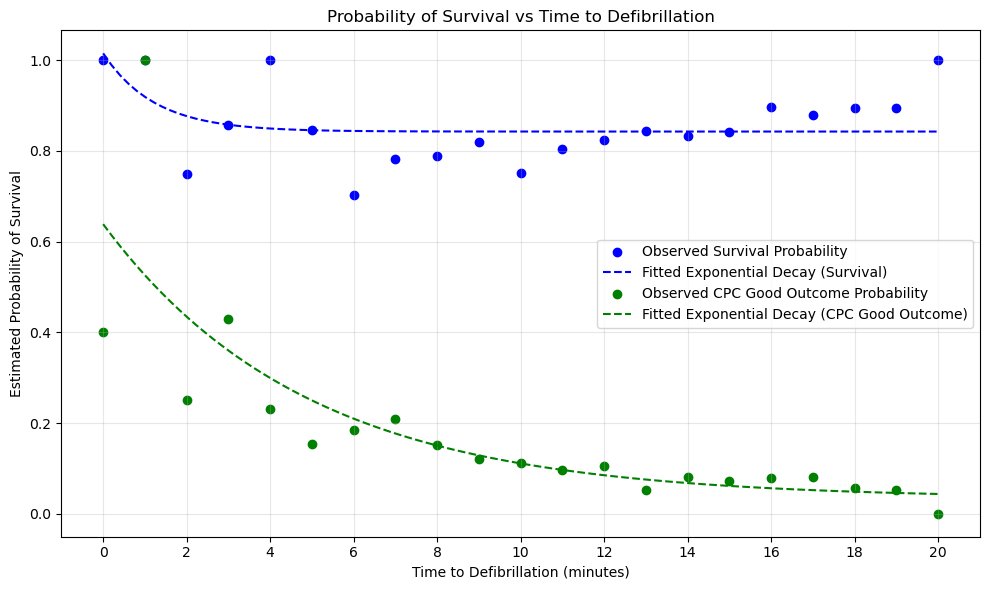

In [38]:
plt.figure(figsize=(10, 6))

# Plot Overall Survival
plt.scatter(survival_prob['Time_Bin'],
            survival_prob['EST_Probability'],
            color='blue',
            label='Observed Survival Probability')
plt.plot(t_smooth,
         fitted_surv,
         color='blue',
         linestyle='--',
         label='Fitted Exponential Decay (Survival)')

# Plot CPC Good Outcome
plt.scatter(cpc_prob['Time_Bin'],
            cpc_prob['CPC_Good_Probability'],
            color='green',
            label='Observed CPC Good Outcome Probability')
plt.plot(t_smooth,
         fitted_cpc,
         color='green',
         linestyle='--',
         label='Fitted Exponential Decay (CPC Good Outcome)')

plt.title("Probability of Survival vs Time to Defibrillation")
plt.xlabel("Time to Defibrillation (minutes)")
plt.ylabel("Estimated Probability of Survival")
plt.xticks(np.arange(0, max_time + 1, 2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()